# Run algorithm on COVID data

CovSpectrum is used to get current Covid variants in a timeframe between 14.10.24 to 16.04.25.

As a first try they are grouped by nextstrain clade. The recombinant variants are filtered out by now, because they are not expected to have the standard exponential growth behavior.

In [2]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.colors

from viral_variant_comp.plotting import plot_viral_composition, plot_heatmap, plot_viral_composition_interactive
from viral_variant_comp.estimate import calculate_viral_composition_stepwise,calculate_viral_composition, calculate_cooccurence, calculate_viral_composition_evofr
from viral_variant_comp.simulate_count_data import reorder_variants_realdata

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
url_switzerland = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=Switzerland&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date"
url_world = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,country"
url_usa = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=USA&dateFrom=2024-01-01&dateTo=2025-04-16&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,nextstrainClade"
response = requests.get(url_usa)

response.raise_for_status() # Raise an error if the request failed
data = response.json()  # Parse the JSON content
counts_df = pd.DataFrame(data['data'])
counts_df.to_csv("data/counts_covid_usa.csv", index=False)

counts_df.head()

,count,date,nextcladePangoLineage,nextstrainClade
0,2,2024-01-12,HK.20.1,23F
1,1,2024-01-25,HK.13,23F
2,2,2024-01-07,JR.1.1,23F
3,1,2024-01-18,EG.5.1.16,23F
4,1,2024-01-02,DV.7.1.4,23C


In [4]:
counts_df = pd.read_csv("data/counts_covid_usa.csv")
counts_df.head()

,count,date,nextcladePangoLineage,nextstrainClade
0,2,2024-01-12,HK.20.1,23F
1,1,2024-01-25,HK.13,23F
2,2,2024-01-07,JR.1.1,23F
3,1,2024-01-18,EG.5.1.16,23F
4,1,2024-01-02,DV.7.1.4,23C


In [5]:
counts_df['date'] = pd.to_datetime(counts_df['date'])
counts_pivot = counts_df.pivot_table(index='date', columns='nextstrainClade', values='count', aggfunc='sum', fill_value=0).sort_index()
counts_pivot = counts_pivot.drop('recombinant', axis = 1)
counts_matrix = counts_pivot.to_numpy()
counts_pivot.head()

nextstrainClade,19A,20B,20I,20J,21C,21I,21K,21L,21M,22A,...,24A,24B,24C,24D,24E,24F,24G,24H,24I,25A
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,1,0,0,0,0,0,0,2,0,0,...,632,0,0,0,0,0,0,0,0,0
2024-01-02,0,0,0,0,0,0,0,2,1,0,...,1326,1,0,0,0,0,0,0,0,0
2024-01-03,0,0,0,0,0,0,0,2,0,0,...,1311,1,0,0,0,0,0,0,0,0
2024-01-04,0,0,0,0,0,0,1,4,0,0,...,1279,0,0,0,0,0,0,0,0,0
2024-01-05,0,0,0,0,0,0,0,3,0,0,...,959,2,0,0,0,0,0,0,0,0


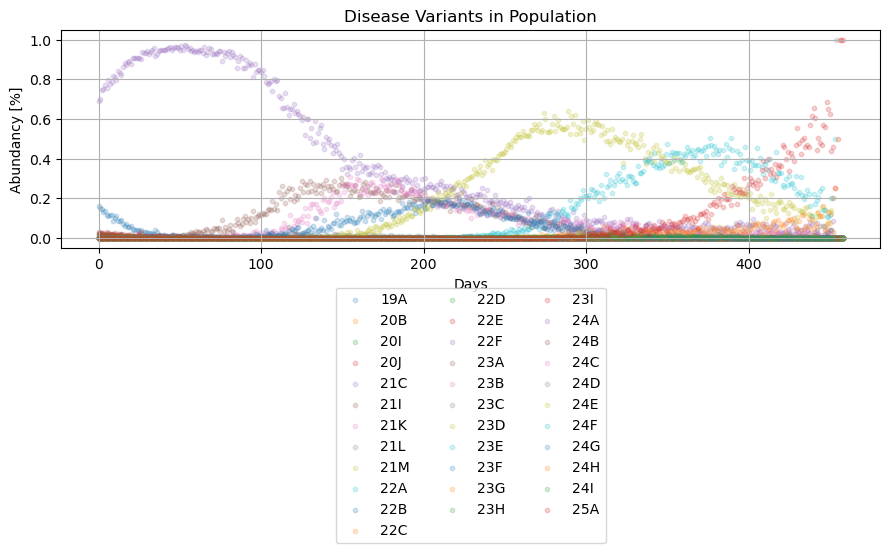

In [6]:
plot_viral_composition(counts_matrix, var_names=counts_pivot.columns, logscale = False)
#plot_viral_composition(data['counts'], data['freq'], y_range = (1e-5, 2), logscale = True)

In [7]:
plot_viral_composition_interactive(counts_matrix, var_names=counts_pivot.columns, logscale = False)

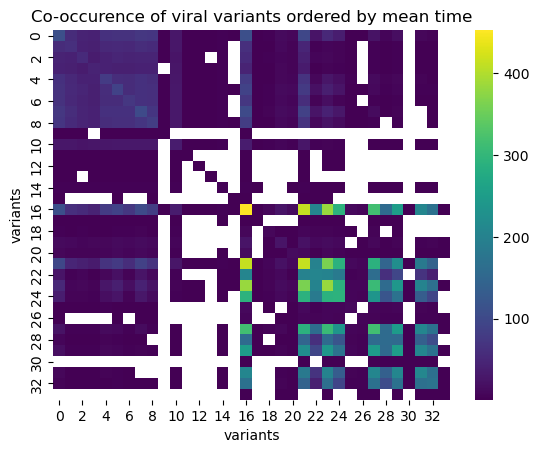

In [8]:
counts, var_names = reorder_variants_realdata(counts_matrix, counts_pivot.columns)
data = {'counts': counts, 'n_variants': counts.shape[1], 'variant_names': var_names}

co_occurence_reorderd = calculate_cooccurence(counts)
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

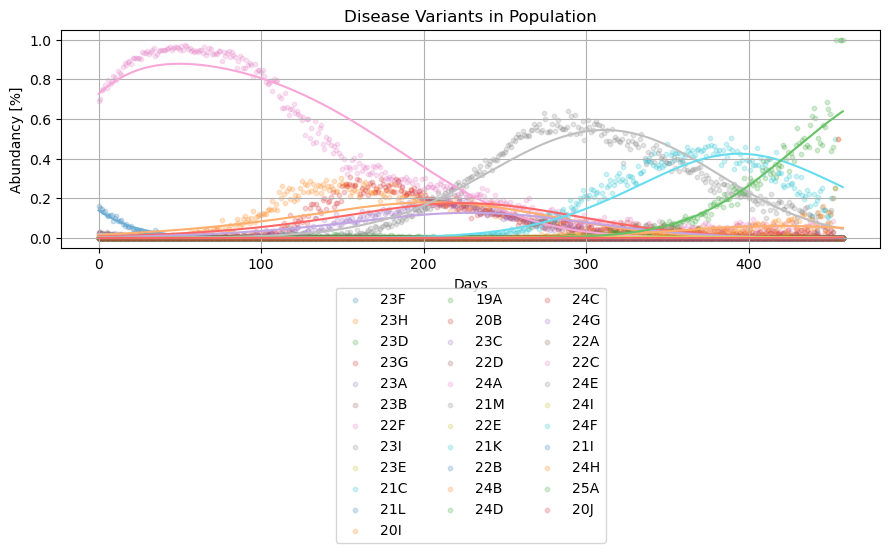

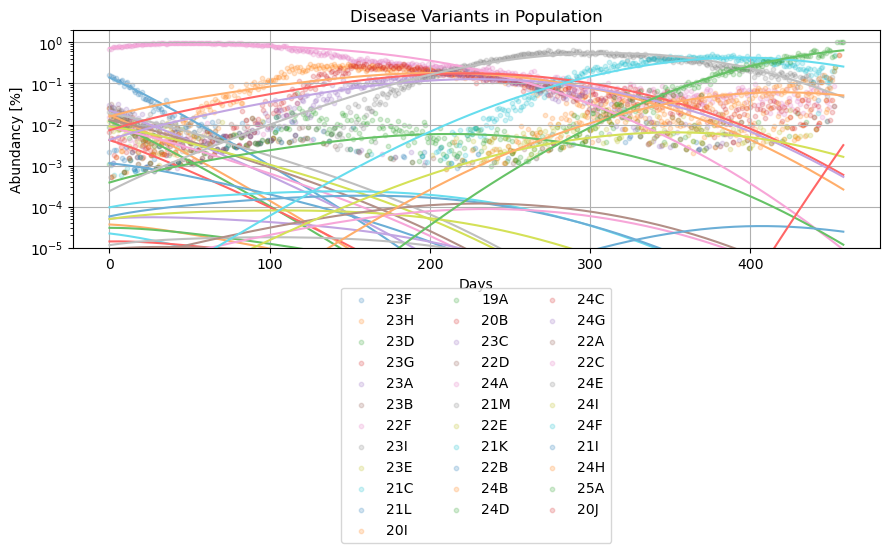

In [9]:
result, composition_estimate = calculate_viral_composition(data)

plot_viral_composition(data['counts'], composition_estimate=composition_estimate, var_names=data['variant_names'], logscale = False)
plot_viral_composition(data['counts'], composition_estimate=composition_estimate,var_names=data['variant_names'], y_range = (1e-5, 2), logscale = True)
plot_viral_composition_interactive(data['counts'],composition_estimate=composition_estimate, var_names=data['variant_names'], logscale = False)

Loop  0
Loop  1
Loop  2
Loop  3
Loop  4
Loop  5


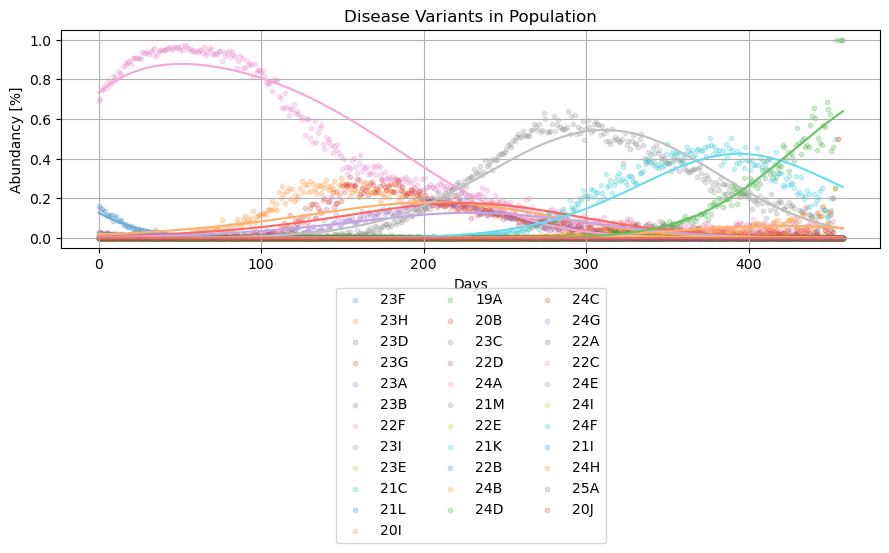

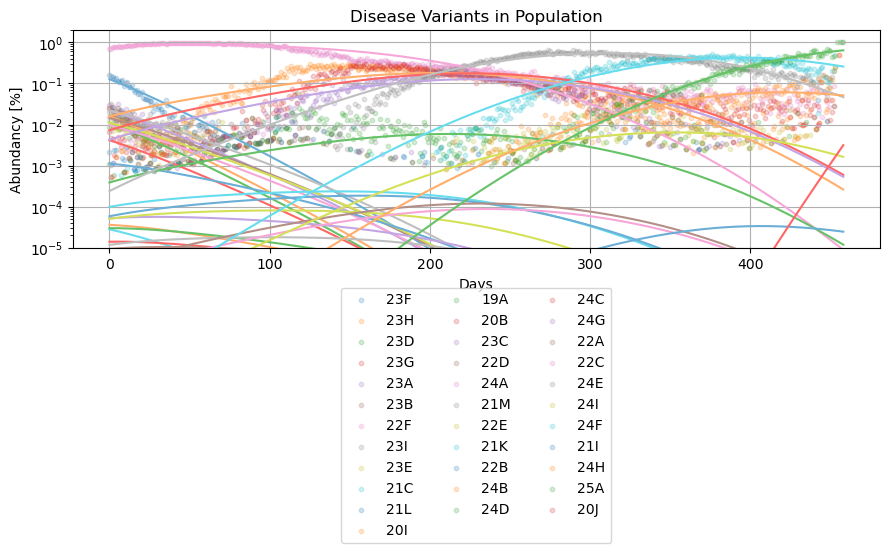

In [10]:
partition_size = 9
overlap_size = 4

result_stepwise = calculate_viral_composition_stepwise(data, partition_size, overlap_size)

plot_viral_composition(data['counts'], composition_estimate=result_stepwise['composition_estimate'], var_names=data['variant_names'], logscale = False)
plot_viral_composition(data['counts'], composition_estimate=result_stepwise['composition_estimate'],var_names=data['variant_names'], y_range = (1e-5, 2), logscale = True)

In [11]:
#counts_df = counts_df[counts_df.date < '2025-03-15']    # counts after this date have counts below 40

#possibly filter out variants with too less counts
#variant_counts = counts_df['nextcladePangoLineage'].value_counts()
#variants_to_keep = variant_counts[variant_counts >= 2].index
#counts_df = counts_df[counts_df['nextcladePangoLineage'].isin(variants_to_keep)]


In [12]:
data.keys()

dict_keys(['counts', 'n_variants', 'variant_names'])

## Compare to evofr

In [16]:
evofr_result = calculate_viral_composition_evofr(data, iterations = 1000000, learning_rate = 4e-3)

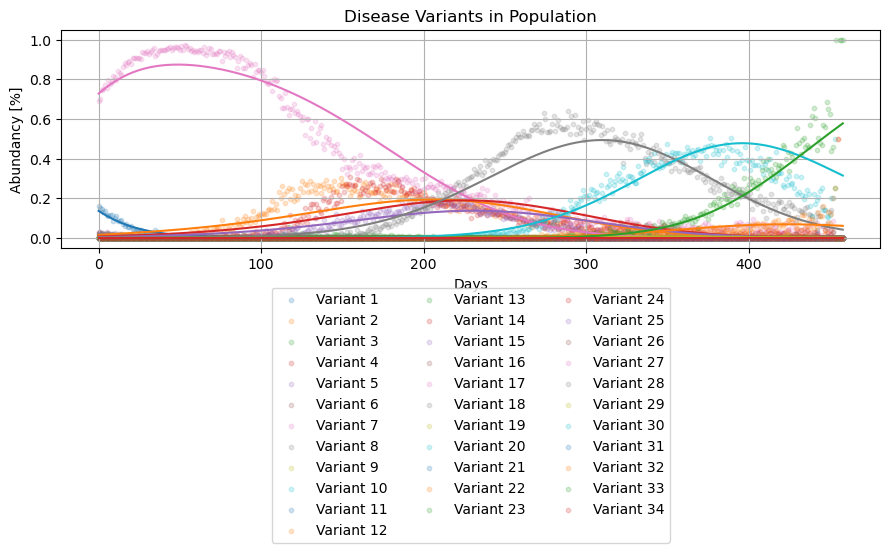

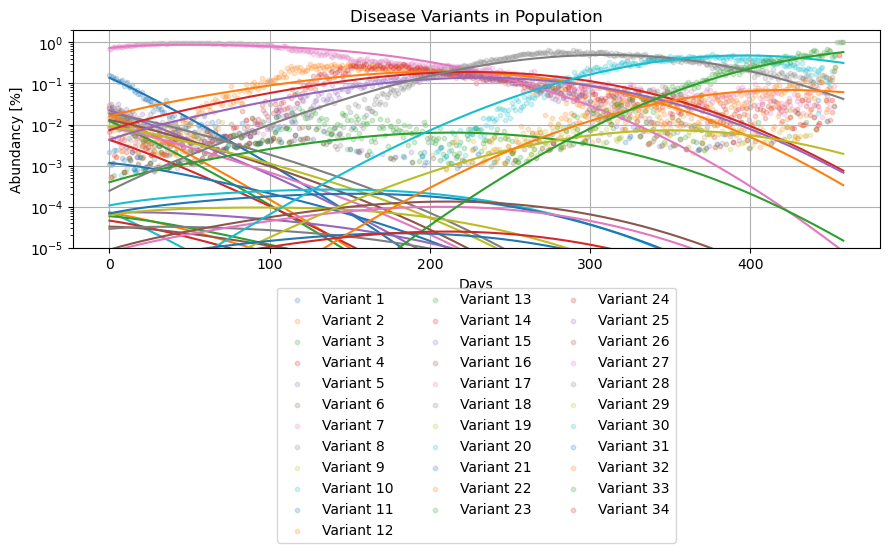

In [17]:
plot_viral_composition(data['counts'], evofr_result['freq'], logscale = False)
plot_viral_composition(data['counts'], evofr_result['freq'], y_range = (1e-5, 2), logscale = True)